In [9]:
pip install pytrends pandas matplotlib

In [10]:
pip install requests beautifulsoup4

Blok 1: Pengambilan Data Google Trends (April 2025 - Maret 2026)

In [11]:
import pandas as pd
from pytrends.request import TrendReq

# 1. Inisialisasi koneksi ke Google Trends
pytrends = TrendReq(hl='id-ID', tz=360)
# 2. Tentukan daftar kata kunci
kw_list = ["badminton"]
# 3. Membangun payload (filter spesifik April 2025 - Maret 2026)
pytrends.build_payload(kw_list, cat=0, timeframe='2025-04-01 2026-03-31', geo='ID', gprop='')
# 4. Ambil data ketertarikan seiring waktu (Interest Over Time)
data = pytrends.interest_over_time()
# Hapus kolom 'isPartial' karena tidak diperlukan
if not data.empty:
    data = data.drop(labels=['isPartial'], axis='columns')
    print("--- DATA GOOGLE TRENDS BERHASIL DIAMBIL ---")
    print(data.head())
    print("...")
    print(data.tail())
else:
    print("Tidak ada data yang ditemukan.")

--- DATA GOOGLE TRENDS BERHASIL DIAMBIL ---
            badminton
date                 
2025-03-30         22
2025-04-06         48
2025-04-13         34
2025-04-20         33
2025-04-27         68
...
            badminton
date                 
2026-03-01         41
2026-03-08         34
2026-03-15         27
2026-03-22         26
2026-03-29         27


Blok 2: Web Scraping Jadwal BWF

In [12]:
import pandas as pd
import requests
from io import StringIO
tahun_list = [2025, 2026]
semua_jadwal = []
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
for tahun in tahun_list:
    url = f"https://id.wikipedia.org/wiki/Tur_Dunia_BWF_{tahun}"
    print(f"Sedang mengambil data dari: {url}...")
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        html_data = StringIO(response.text)
        try:
            daftar_tabel = pd.read_html(html_data, match='Turnamen')
            df_tahun = pd.concat(daftar_tabel, ignore_index=True)
            df_tahun = df_tahun[['Tanggal', 'Turnamen']].dropna()
            df_tahun['Tahun'] = tahun
            semua_jadwal.append(df_tahun)
            print(f"✅ Berhasil mengambil data tahun {tahun}.")
        except ValueError:
            print(f"❌ Tabel tidak ditemukan untuk tahun {tahun}.")
    else:
        print(f"❌ Gagal mengakses halaman tahun {tahun}.")
print("\n--- PROSES SCRAPING SELESAI ---")

Sedang mengambil data dari: https://id.wikipedia.org/wiki/Tur_Dunia_BWF_2025...
✅ Berhasil mengambil data tahun 2025.
Sedang mengambil data dari: https://id.wikipedia.org/wiki/Tur_Dunia_BWF_2026...
✅ Berhasil mengambil data tahun 2026.

--- PROSES SCRAPING SELESAI ---


Blok 3: Pembersihan Teks & Filter Rentang Waktu

In [13]:
import re
from datetime import datetime

# 1. Gabungkan dan hapus duplikat
df_mentah = pd.concat(semua_jadwal, ignore_index=True)
df_mentah = df_mentah.drop_duplicates(subset=['Tanggal', 'Turnamen', 'Tahun']).copy()

# 2. Ekstrak Level dan Nama Turnamen
df_mentah['Level'] = df_mentah['Turnamen'].str.extract(r'(Super\s*\d+|Final Tur)', expand=False).fillna('Lainnya')
df_mentah['Nama_Turnamen'] = df_mentah['Turnamen'].str.split(r'\(Hasil\)|Tuan').str[0].str.strip()

# 3. Fungsi Konversi Datetime
bulan_map = {'Januari': '01', 'Februari': '02', 'Maret': '03', 'April': '04',
             'Mei': '05', 'Juni': '06', 'Juli': '07', 'Agustus': '08',
             'September': '09', 'Oktober': '10', 'November': '11', 'Desember': '12'}
def extract_end_datetime(row):
    tahun = row['Tahun']
    tanggal_str = row['Tanggal']
    match = re.search(r'(\d+)\s+([A-Za-z]+)$', tanggal_str)
    if match:
        tanggal_akhir, bulan_nama = match.group(1), match.group(2)
        if bulan_map.get(bulan_nama):
            return pd.to_datetime(f"{tahun}-{bulan_map.get(bulan_nama)}-{tanggal_akhir.zfill(2)}")
    match_cross = re.search(r'([A-Za-z]+)$', tanggal_str)
    if match_cross:
        bulan_akhir_nama = match_cross.group(1)
        tanggal_akhir_cross = re.search(r'(\d+)', tanggal_str.split('–')[-1])
        if tanggal_akhir_cross and bulan_map.get(bulan_akhir_nama):
            return pd.to_datetime(f"{tahun}-{bulan_map.get(bulan_akhir_nama)}-{tanggal_akhir_cross.group(1).zfill(2)}")
    return pd.NaT
df_mentah['Puncak_Acara'] = df_mentah.apply(extract_end_datetime, axis=1)
df_mentah = df_mentah.dropna(subset=['Puncak_Acara'])

# 4. KUNCI RENTANG WAKTU: Filter hanya untuk April 2025 - Maret 2026
start_date = pd.to_datetime('2025-04-01')
end_date = pd.to_datetime('2026-03-31')
df_schedule_filtered = df_mentah[(df_mentah['Puncak_Acara'] >= start_date) &
                                 (df_mentah['Puncak_Acara'] <= end_date)].copy()

print("--- DATA JADWAL BERSIH DAN SIAP DIGUNAKAN ---")
print(f"Total turnamen dari April 2025 - Maret 2026: {len(df_schedule_filtered)}")
print(df_schedule_filtered[['Puncak_Acara', 'Nama_Turnamen', 'Level']].head())

--- DATA JADWAL BERSIH DAN SIAP DIGUNAKAN ---
Total turnamen dari April 2025 - Maret 2026: 39
    Puncak_Acara      Nama_Turnamen       Level
100   2025-05-11     Taipei Terbuka   Super 300
110   2025-05-18   Thailand Terbuka   Super 500
120   2025-05-25   Malaysia Masters   Super 500
130   2025-06-01  Singapura Terbuka   Super 750
140   2025-06-08  Indonesia Terbuka  Super 1000


Blok 4: EDA Karakteristik Jadwal Turnamen (Bar & Pie Chart)

/tmp/ipykernel_746/1447839888.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=turnamen_per_bulan.index, y=turnamen_per_bulan.values, ax=axes[0], palette='viridis')


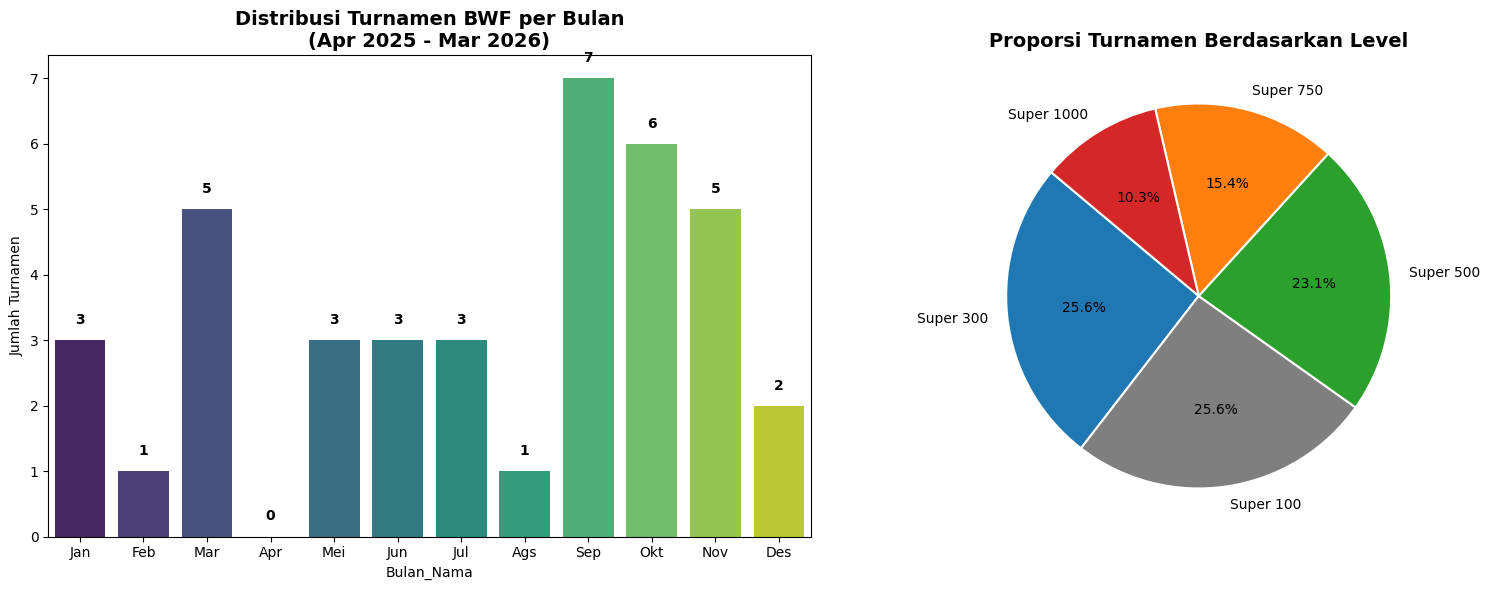

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eda_jadwal = df_schedule_filtered.copy()

# Siapkan canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Distribusi per Bulan
bulan_map_id = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
                7: 'Jul', 8: 'Ags', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'}
df_eda_jadwal['Bulan_Nama'] = df_eda_jadwal['Puncak_Acara'].dt.month.map(bulan_map_id)
turnamen_per_bulan = df_eda_jadwal['Bulan_Nama'].value_counts().reindex(list(bulan_map_id.values())).fillna(0)

sns.barplot(x=turnamen_per_bulan.index, y=turnamen_per_bulan.values, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Turnamen BWF per Bulan\n(Apr 2025 - Mar 2026)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Turnamen')
for i, v in enumerate(turnamen_per_bulan.values):
    axes[0].text(i, v + 0.2, str(int(v)), ha='center', va='bottom', fontweight='bold')

# Chart 2: Proporsi Level Series
distribusi_level = df_eda_jadwal['Level'].value_counts()
warna_level_map = {'Final Tur': '#d62728', 'Super 1000': '#d62728', 'Super 750': '#ff7f0e',
                   'Super 500': '#2ca02c', 'Super 300': '#1f77b4', 'Super 100': '#7f7f7f', 'Lainnya': '#c7c7c7'}
warna_pie = [warna_level_map.get(x, '#333333') for x in distribusi_level.index]

axes[1].pie(distribusi_level.values, labels=distribusi_level.index, autopct='%1.1f%%',
            startangle=140, colors=warna_pie, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi Turnamen Berdasarkan Level', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Blok 5: Penggabungan Data & Statistik Deskriptif


--- STATISTIKA DESKRIPTIF VOLUME PENCARIAN ---
                  Rata_rata  Median  Min  Max  Jumlah_Minggu
Kondisi_Minggu                                              
Super 750             79.50    78.0   66  100              6
Super 100             68.00    63.0   56   90              4
Super 500             58.78    55.0   49   72              9
Super 1000            52.50    48.5   34   79              4
Super 300             44.90    46.0   26   67             10
Turnamen Lainnya      43.65    41.0   22   82             20


/tmp/ipykernel_746/3067785005.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bulan', y='badminton', data=df_eda, order=urutan_bulan, errorbar='sd', palette='Blues_d')


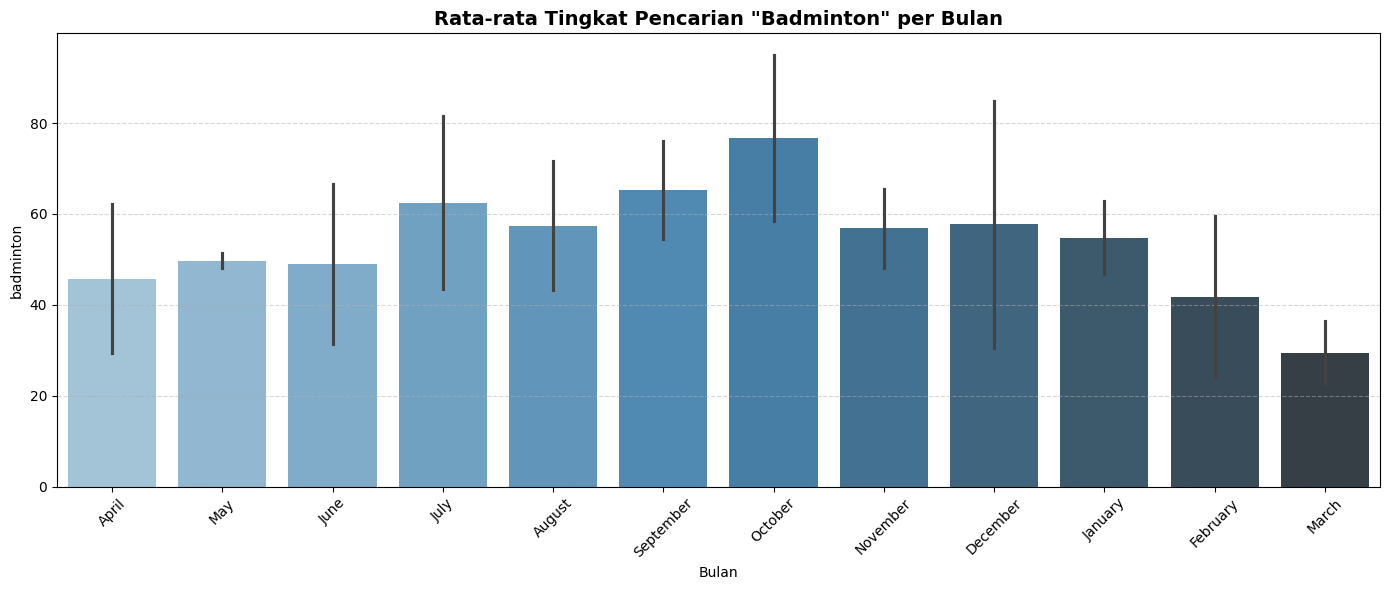

In [15]:
# 1. Labeling Minggu Tren dengan Turnamen
df_eda = data.copy().reset_index()
df_eda.rename(columns={df_eda.columns[0]: 'Tanggal_Trend'}, inplace=True)

def get_tournament_level(tanggal_trend):
    mask = (df_schedule_filtered['Puncak_Acara'] >= tanggal_trend - pd.Timedelta(days=3)) & \
           (df_schedule_filtered['Puncak_Acara'] <= tanggal_trend + pd.Timedelta(days=4))
    turnamen_minggu_ini = df_schedule_filtered[mask]
    if not turnamen_minggu_ini.empty:
        levels = turnamen_minggu_ini['Level'].tolist()
        for p in ['Final Tur', 'Super 1000', 'Super 750', 'Super 500', 'Super 300', 'Super 100']:
            if p in levels: return p
        return levels[0]
    return 'Turnamen Lainnya'

df_eda['Kondisi_Minggu'] = df_eda['Tanggal_Trend'].apply(get_tournament_level)

# 2. Statistik Deskriptif
tabel_deskriptif = df_eda.groupby('Kondisi_Minggu')['badminton'].agg(
    Rata_rata='mean', Median='median', Min='min', Max='max', Jumlah_Minggu='count'
).round(2).sort_values(by='Rata_rata', ascending=False)
print("\n--- STATISTIKA DESKRIPTIF VOLUME PENCARIAN ---")
print(tabel_deskriptif)

# 3. Bar Chart Agregasi Tren Bulanan
df_eda['Bulan'] = df_eda['Tanggal_Trend'].dt.month_name()
urutan_bulan = ['April', 'May', 'June', 'July', 'August', 'September',
                'October', 'November', 'December', 'January', 'February', 'March']

plt.figure(figsize=(14, 6))
sns.barplot(x='Bulan', y='badminton', data=df_eda, order=urutan_bulan, errorbar='sd', palette='Blues_d')
plt.title('Rata-rata Tingkat Pencarian "Badminton" per Bulan', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Blok 6: Visualisasi Korelasi (Overlay Chart)

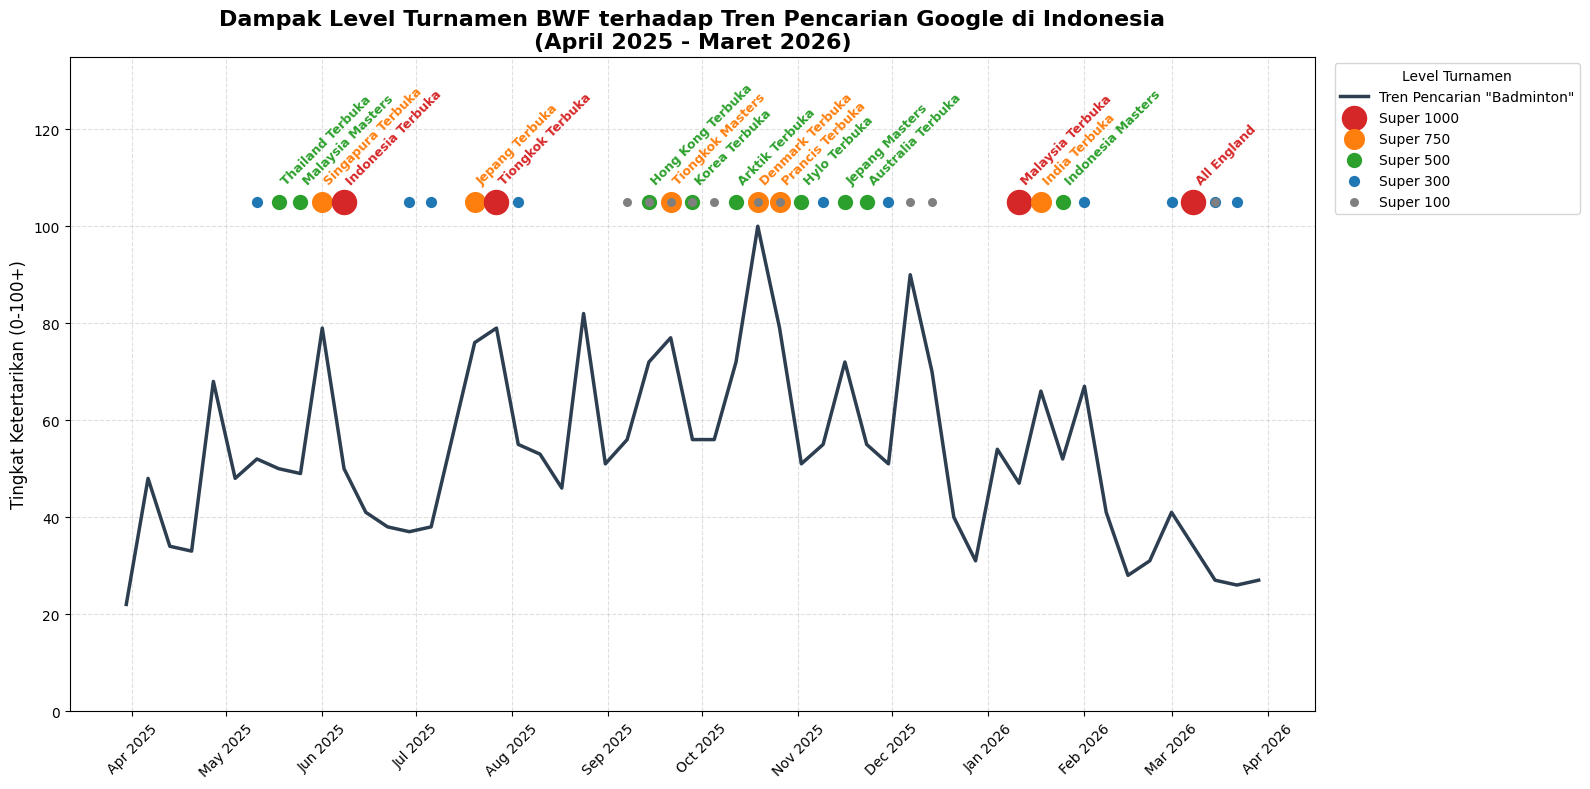

In [16]:
import matplotlib.dates as mdates
color_map = {'Final Tur': '#d62728', 'Super 1000': '#d62728', 'Super 750': '#ff7f0e',
             'Super 500': '#2ca02c', 'Super 300': '#1f77b4', 'Super 100': '#7f7f7f', 'Lainnya': '#c7c7c7'}
size_map = {'Final Tur': 300, 'Super 1000': 300, 'Super 750': 200,
            'Super 500': 100, 'Super 300': 50, 'Super 100': 30, 'Lainnya': 20}

plt.figure(figsize=(16, 8))
plt.plot(data.index, data['badminton'], color='#2c3e50', linewidth=2.5, label='Tren Pencarian "Badminton"')
levels_plotted = []
for index, row in df_schedule_filtered.iterrows():
    lvl = row['Level']
    if lvl not in levels_plotted:
        plt.scatter(row['Puncak_Acara'], 105, color=color_map.get(lvl, 'black'), s=size_map.get(lvl, 50), label=lvl, zorder=5)
        levels_plotted.append(lvl)
    else:
        plt.scatter(row['Puncak_Acara'], 105, color=color_map.get(lvl, 'black'), s=size_map.get(lvl, 50), zorder=5)
    if lvl in ['Super 1000', 'Super 750', 'Super 500', 'Final Tur']:
        plt.text(row['Puncak_Acara'], 108, row['Nama_Turnamen'], rotation=45, color=color_map.get(lvl, 'black'), fontsize=9, ha='left',
                 va='bottom', fontweight='bold')
plt.title('Dampak Level Turnamen BWF terhadap Tren Pencarian Google di Indonesia\n(April 2025 - Maret 2026)', fontsize=16,
          fontweight='bold')
plt.ylabel('Tingkat Ketertarikan (0-100+)', fontsize=12)
plt.ylim(0, 135)

# Mengurutkan Legend
handles, labels = plt.gca().get_legend_handles_labels()
urutan_legend = {'Tren Pencarian "Badminton"': 0, 'Final Tur': 1, 'Super 1000': 2, 'Super 750': 3, 'Super 500': 4, 'Super 300': 5, 'Super 100': 6, 'Lainnya': 7}
pasangan_urut = sorted(zip(handles, labels), key=lambda x: urutan_legend.get(x[1], 99))
handles_urut, labels_urut = zip(*pasangan_urut)

plt.legend(handles_urut, labels_urut, bbox_to_anchor=(1.01, 1), loc='upper left', title="Level Turnamen")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()